In [2]:
from pathlib import Path
import shutil

PROJECT_DIR = Path.cwd()

DATA_DIR = PROJECT_DIR / "data"
BASE_PATH = DATA_DIR / "OCT2017" / "OCT2017"
MODELS_DIR = PROJECT_DIR / "models"
OUTPUTS_DIR = PROJECT_DIR / "outputs"
ZIP_PATH = DATA_DIR / "kermany2018.zip"

DATA_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

# paths
project_dir = PROJECT_DIR
data_dir = DATA_DIR
base_path = BASE_PATH
models_dir = MODELS_DIR
outputs_dir = OUTPUTS_DIR
zip_path = ZIP_PATH
extract_to = DATA_DIR



In [ ]:
project_dir = PROJECT_DIR
data_dir = DATA_DIR

project_dir.mkdir(parents=True, exist_ok=True)
data_dir.mkdir(parents=True, exist_ok=True)

print("Project folder:", project_dir)
print("Data folder:", data_dir)

In [ ]:
import sys
import subprocess

subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "kaggle"])
print("Kaggle package installed/upgraded.")

In [ ]:
python_dir = Path(sys.executable).parent
kaggle_exe = python_dir / "Scripts" / "kaggle.exe"

print("Python executable:", sys.executable)
print("Kaggle executable:", kaggle_exe)
print("Kaggle executable exists:", kaggle_exe.exists())

In [ ]:
import subprocess

result = subprocess.run(
    [str(kaggle_exe), "datasets", "list", "-s", "kermany2018"],
    capture_output=True,
    text=True
)

print("Return code:", result.returncode)
print(result.stdout)
print(result.stderr)

In [ ]:
import sys
import subprocess
from pathlib import Path

python_dir = Path(sys.executable).parent
kaggle_exe = python_dir / "Scripts" / "kaggle.exe"

print("Kaggle executable:", kaggle_exe)
print("Exists:", kaggle_exe.exists())

subprocess.run([str(kaggle_exe), "auth", "login"], text=True)

In [ ]:
import subprocess

result = subprocess.run(
    [str(kaggle_exe), "datasets", "list", "-s", "kermany2018"],
    capture_output=True,
    text=True
)

print("Return code:", result.returncode)
print(result.stdout)
print(result.stderr)

In [ ]:
from pathlib import Path
import subprocess

data_dir = DATA_DIR
data_dir.mkdir(parents=True, exist_ok=True)

result = subprocess.run(
    [
        str(kaggle_exe),
        "datasets",
        "download",
        "-d", "paultimothymooney/kermany2018",
        "-p", str(data_dir),
        "--force"
    ],
    text=True
)

print("Download command finished.")

In [ ]:
import subprocess

result = subprocess.run(
    [str(kaggle_exe), "datasets", "list", "-s", "kermany2018"],
    capture_output=True,
    text=True
)

print("Return code:", result.returncode)
print(result.stdout)
print(result.stderr)

In [ ]:
from pathlib import Path
import zipfile

zip_path = ZIP_PATH

print("Zip exists:", zip_path.exists())

if zip_path.exists():
    print("Zip size in GB:", round(zip_path.stat().st_size / (1024**3), 2))
    print("Is zip file:", zipfile.is_zipfile(zip_path))

In [ ]:
import zipfile

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    bad_file = zip_ref.testzip()

print("First bad file:", bad_file)

In [ ]:
import zipfile
from pathlib import Path
import shutil

zip_path = ZIP_PATH
extract_to = DATA_DIR
failed_files = []

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    members = zip_ref.infolist()
    print("Total files/folders in zip:", len(members))

    for i, member in enumerate(members):
        try:
            # Skip Mac system files
            if "__MACOSX" in member.filename:
                continue

            # Clean weird folder names like "OCT2017 " with trailing space
            cleaned_parts = [part.strip() for part in Path(member.filename).parts]
            cleaned_name = Path(*cleaned_parts)
            target_path = extract_to / cleaned_name

            if member.is_dir():
                target_path.mkdir(parents=True, exist_ok=True)
            else:
                target_path.parent.mkdir(parents=True, exist_ok=True)

                with zip_ref.open(member) as source, open(target_path, "wb") as target:
                    shutil.copyfileobj(source, target, length=1024 * 1024)

        except Exception as e:
            failed_files.append((member.filename, str(e)))

        if i % 5000 == 0:
            print(f"Processed {i}/{len(members)}")

print("\nExtraction completed.")
print("Failed files:", len(failed_files))

for file, error in failed_files[:10]:
    print(file, "----", error)

In [ ]:
from pathlib import Path
from collections import defaultdict

data_dir = DATA_DIR

classes = {"CNV", "DME", "DRUSEN", "NORMAL"}
splits = {"train", "test", "val"}

candidate_roots = defaultdict(int)

for img in data_dir.rglob("*"):
    if img.suffix.lower() in [".jpeg", ".jpg", ".png"]:
        class_name = img.parent.name
        split_name = img.parent.parent.name
        root = img.parent.parent.parent

        if class_name in classes and split_name in splits:
            candidate_roots[str(root)] += 1

print("Possible dataset roots:")
for root, count in sorted(candidate_roots.items(), key=lambda x: x[1], reverse=True):
    print(root, "----", count, "images")

In [ ]:
from pathlib import Path

base_path = BASE_PATH

print("Base path exists:", base_path.exists())
print("Folders:", list(base_path.iterdir()))

In [16]:
for split in ["train", "val", "test"]:
    print("\n", split.upper())
    for cls in ["CNV", "DME", "DRUSEN", "NORMAL"]:
        folder = base_path / split / cls
        count = len(list(folder.glob("*.jpeg")))
        print(cls, count)


 TRAIN
CNV 37205
DME 11348
DRUSEN 8616
NORMAL 26315

 VAL
CNV 8
DME 8
DRUSEN 8
NORMAL 8

 TEST
CNV 242
DME 242
DRUSEN 242
NORMAL 242


In [18]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from tensorflow.keras.utils import to_categorical

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.12.0


In [ ]:
train_full_dir = base_path / "train"
test_dir = base_path / "test"

img_size = (160, 160)
batch_size = 32
seed = 42

print("Training folder:", train_full_dir)
print("Testing folder:", test_dir)

In [28]:
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    train_full_dir,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="int"
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    train_full_dir,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="int"
)

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="int",
    shuffle=False
)

class_names = train_ds_raw.class_names
print("Class names:", class_names)

Found 83484 files belonging to 4 classes.
Using 66788 files for training.
Found 83484 files belonging to 4 classes.
Using 16696 files for validation.
Found 968 files belonging to 4 classes.
Class names: ['CNV', 'DME', 'DRUSEN', 'NORMAL']


In [29]:
class_counts = {}

for cls in class_names:
    class_counts[cls] = len(list((train_full_dir / cls).glob("*.jpeg")))

print("Class counts:", class_counts)

labels_for_weights = []

for idx, cls in enumerate(class_names):
    labels_for_weights.extend([idx] * class_counts[cls])

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels_for_weights),
    y=labels_for_weights
)

class_weights = {i: weight for i, weight in enumerate(class_weights_array)}

print("\nClass weights:")
for i, weight in class_weights.items():
    print(class_names[i], ":", round(weight, 3))

Class counts: {'CNV': 37205, 'DME': 11348, 'DRUSEN': 8616, 'NORMAL': 26315}

Class weights:
CNV : 0.561
DME : 1.839
DRUSEN : 2.422
NORMAL : 0.793


In [30]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds_raw.prefetch(AUTOTUNE)
val_ds = val_ds_raw.prefetch(AUTOTUNE)
test_ds = test_ds_raw.prefetch(AUTOTUNE)

In [31]:
from tensorflow.keras import layers, models

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name="data_augmentation")


def build_transfer_model(model_name, input_shape=(160, 160, 3), num_classes=4):
    inputs = layers.Input(shape=input_shape)

    x = data_augmentation(inputs)

    if model_name == "MobileNetV2":
        x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
        base_model = tf.keras.applications.MobileNetV2(
            include_top=False,
            weights="imagenet",
            input_shape=input_shape
        )

    elif model_name == "EfficientNetB0":
        # EfficientNet preprocessing is built into the Keras model.
        base_model = tf.keras.applications.EfficientNetB0(
            include_top=False,
            weights="imagenet",
            input_shape=input_shape
        )

    else:
        raise ValueError("Choose either 'MobileNetV2' or 'EfficientNetB0'.")

    base_model.trainable = False

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs, name=model_name)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [36]:
def train_model(model_name, epochs=3, steps_per_epoch=250, validation_steps=60):
    print(f"\nTraining {model_name}...\n")

    model = build_transfer_model(
        model_name=model_name,
        input_shape=(160, 160, 3),
        num_classes=len(class_names)
    )

    checkpoint_path = models_dir / f"best_{model_name}.weights.h5"

    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(checkpoint_path),
            monitor="val_accuracy",
            save_best_only=True,
            save_weights_only=True,
            mode="max",
            verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True,
            verbose=1
        )
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        validation_steps=validation_steps,
        class_weight=class_weights,
        callbacks=callbacks
    )

    return model, history

In [38]:
mobilenet_model, mobilenet_history = train_model(
    "MobileNetV2",
    epochs=10,
    steps_per_epoch=250,
    validation_steps=60
)


Training MobileNetV2...

Epoch 1/10
250/250 [==============================] - ETA: 0s - loss: 1.3115 - accuracy: 0.4654
Epoch 1: val_accuracy improved from -inf to 0.62344, saving model to C:\Users\chand\Documents\OCT_Project\models\best_MobileNetV2.weights.h5
250/250 [==============================] - 140s 531ms/step - loss: 1.3115 - accuracy: 0.4654 - val_loss: 0.9177 - val_accuracy: 0.6234
Epoch 2/10
250/250 [==============================] - ETA: 0s - loss: 0.9723 - accuracy: 0.6346
Epoch 2: val_accuracy improved from 0.62344 to 0.71042, saving model to C:\Users\chand\Documents\OCT_Project\models\best_MobileNetV2.weights.h5
250/250 [==============================] - 116s 463ms/step - loss: 0.9723 - accuracy: 0.6346 - val_loss: 0.7505 - val_accuracy: 0.7104
Epoch 3/10
250/250 [==============================] - ETA: 0s - loss: 0.8756 - accuracy: 0.6762
Epoch 3: val_accuracy did not improve from 0.71042
250/250 [==============================] - 114s 458ms/step - loss: 0.8756 - accu

In [37]:
efficientnet_model, efficientnet_history = train_model(
    "EfficientNetB0",
    epochs=10,
    steps_per_epoch=250,
    validation_steps=60
)


Training EfficientNetB0...

Epoch 1/10
250/250 [==============================] - ETA: 0s - loss: 1.1507 - accuracy: 0.5429
Epoch 1: val_accuracy improved from -inf to 0.61406, saving model to C:\Users\chand\Documents\OCT_Project\models\best_EfficientNetB0.weights.h5
250/250 [==============================] - 199s 750ms/step - loss: 1.1507 - accuracy: 0.5429 - val_loss: 0.9454 - val_accuracy: 0.6141
Epoch 2/10
250/250 [==============================] - ETA: 0s - loss: 0.9190 - accuracy: 0.6709
Epoch 2: val_accuracy improved from 0.61406 to 0.69115, saving model to C:\Users\chand\Documents\OCT_Project\models\best_EfficientNetB0.weights.h5
250/250 [==============================] - 194s 776ms/step - loss: 0.9190 - accuracy: 0.6709 - val_loss: 0.7833 - val_accuracy: 0.6911
Epoch 3/10
250/250 [==============================] - ETA: 0s - loss: 0.8409 - accuracy: 0.6961
Epoch 3: val_accuracy did not improve from 0.69115
250/250 [==============================] - 191s 763ms/step - loss: 0.84

In [39]:
mobilenet_model.load_weights(
    MODELS_DIR / "best_MobileNetV2.weights.h5"
)

print("Best MobileNetV2 weights loaded.")

Best MobileNetV2 weights loaded.


In [40]:
efficientnet_model.load_weights(
    MODELS_DIR / "best_EfficientNetB0.weights.h5"
)

print("Best EfficientNetB0 weights loaded.")

Best EfficientNetB0 weights loaded.


In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from tensorflow.keras.utils import to_categorical

def evaluate_model(model, dataset, class_names, model_name):
    y_true = []
    y_pred_probs = []

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_pred_probs.extend(preds)
        y_true.extend(labels.numpy())

    y_true = np.array(y_true)
    y_pred_probs = np.array(y_pred_probs)
    y_pred = np.argmax(y_pred_probs, axis=1)

    print(f"\nClassification Report: {model_name}")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(7, 7))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )
    disp.plot(ax=ax, values_format="d")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    y_true_onehot = to_categorical(y_true, num_classes=len(class_names))

    auc_score = roc_auc_score(
        y_true_onehot,
        y_pred_probs,
        multi_class="ovr"
    )

    accuracy = np.mean(y_true == y_pred)

    return {
        "model": model_name,
        "accuracy": round(accuracy, 4),
        "roc_auc": round(auc_score, 4)
    }


Classification Report: MobileNetV2
              precision    recall  f1-score   support

         CNV       0.71      0.94      0.81       242
         DME       0.79      0.89      0.84       242
      DRUSEN       0.89      0.63      0.74       242
      NORMAL       0.95      0.81      0.88       242

    accuracy                           0.82       968
   macro avg       0.84      0.82      0.82       968
weighted avg       0.84      0.82      0.82       968



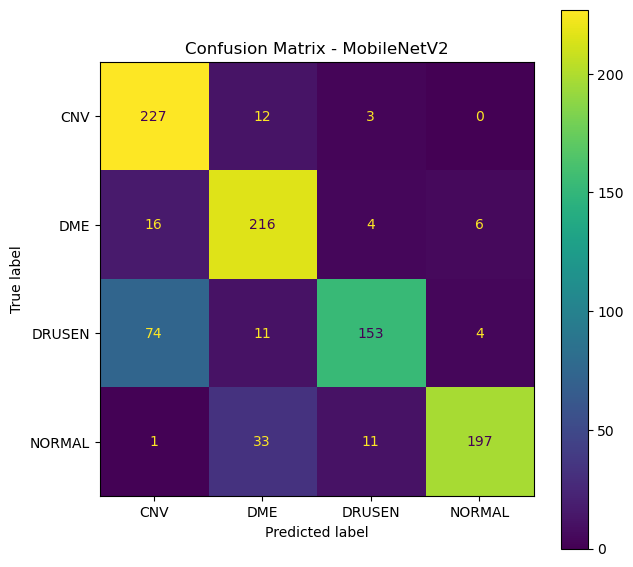

In [43]:
mobilenet_results = evaluate_model(
    mobilenet_model,
    test_ds,
    class_names,
    "MobileNetV2"
)


Classification Report: EfficientNetB0
              precision    recall  f1-score   support

         CNV       0.74      0.94      0.83       242
         DME       0.84      0.90      0.87       242
      DRUSEN       0.85      0.66      0.74       242
      NORMAL       0.97      0.85      0.91       242

    accuracy                           0.84       968
   macro avg       0.85      0.84      0.84       968
weighted avg       0.85      0.84      0.84       968



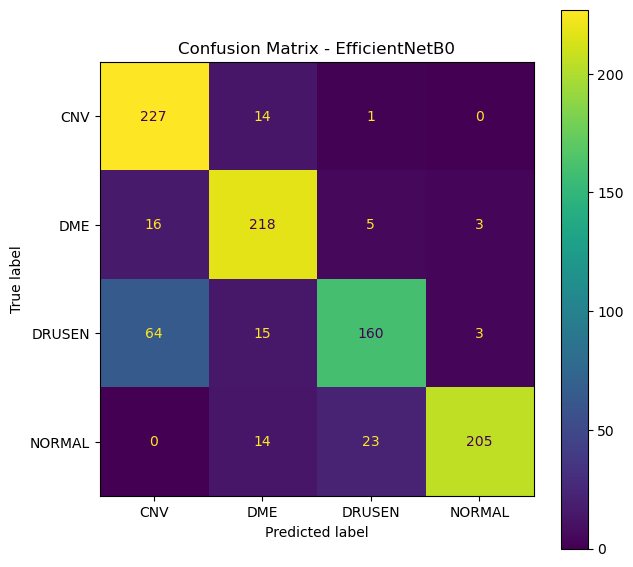

In [44]:
efficientnet_results = evaluate_model(
    efficientnet_model,
    test_ds,
    class_names,
    "EfficientNetB0"
)

In [45]:
import pandas as pd

comparison_df = pd.DataFrame([
    mobilenet_results,
    efficientnet_results
])

comparison_df

,model,accuracy,roc_auc
0,MobileNetV2,0.8192,0.9718
1,EfficientNetB0,0.8368,0.9757


In [46]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image


def get_efficientnet_base_model(model):
    """
    Finds the nested EfficientNetB0 base model inside the full transfer learning model.
    """
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model) and "efficientnet" in layer.name.lower():
            return layer
    
    raise ValueError("EfficientNet base model not found inside the model.")


def find_last_conv_layer(base_model):
    """
    Finds the last Conv2D layer inside the EfficientNetB0 base model.
    """
    for layer in reversed(base_model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    
    raise ValueError("No Conv2D layer found in the base model.")


def build_gradcam_model(model):
    """
    Builds a model that outputs both:
    1. Last convolutional feature maps
    2. Final prediction probabilities
    """
    base_model = get_efficientnet_base_model(model)
    last_conv_layer_name = find_last_conv_layer(base_model)
    
    print("Base model:", base_model.name)
    print("Last convolutional layer:", last_conv_layer_name)

    last_conv_output = base_model.get_layer(last_conv_layer_name).output
    
    # Reuse classifier layers after the base model
    x = base_model.output
    use_layers = False
    
    for layer in model.layers:
        if layer is base_model:
            use_layers = True
            continue
        
        if use_layers:
            try:
                x = layer(x, training=False)
            except TypeError:
                x = layer(x)
    
    grad_model = tf.keras.Model(
        inputs=base_model.input,
        outputs=[last_conv_output, x]
    )
    
    return grad_model


def make_gradcam_heatmap(img_array, grad_model, pred_index=None):
    """
    Creates Grad-CAM heatmap for one image.
    """
    with tf.GradientTape() as tape:
        last_conv_outputs, predictions = grad_model(img_array, training=False)
        
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        
        class_score = predictions[:, pred_index]

    grads = tape.gradient(class_score, last_conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_outputs = last_conv_outputs[0]

    heatmap = last_conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy(), predictions.numpy()[0]


def load_image_for_gradcam(img_path, img_size=(160, 160)):
    """
    Loads and resizes image for the trained model.
    """
    img = tf.keras.utils.load_img(img_path, target_size=img_size)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    return img_array


def overlay_heatmap_on_image(img_path, heatmap, img_size=(160, 160), alpha=0.4):
    """
    Overlays Grad-CAM heatmap on the original OCT image.
    """
    img = tf.keras.utils.load_img(img_path, target_size=img_size)
    img = tf.keras.utils.img_to_array(img)

    heatmap_img = Image.fromarray(np.uint8(255 * heatmap))
    heatmap_img = heatmap_img.resize(img_size)
    heatmap = np.array(heatmap_img) / 255.0

    colormap = plt.cm.jet(heatmap)[:, :, :3]
    colormap = np.uint8(255 * colormap)

    superimposed_img = colormap * alpha + img * (1 - alpha)
    superimposed_img = np.uint8(superimposed_img)

    return np.uint8(img), superimposed_img

In [ ]:
grad_model = build_gradcam_model(efficientnet_model)

In [ ]:
test_dir = base_path / "test"

sample_images = []

for cls in class_names:
    class_folder = test_dir / cls
    first_image = list(class_folder.glob("*.jpeg"))[0]
    sample_images.append((cls, first_image))

for true_class, img_path in sample_images:
    print(true_class, ":", img_path)

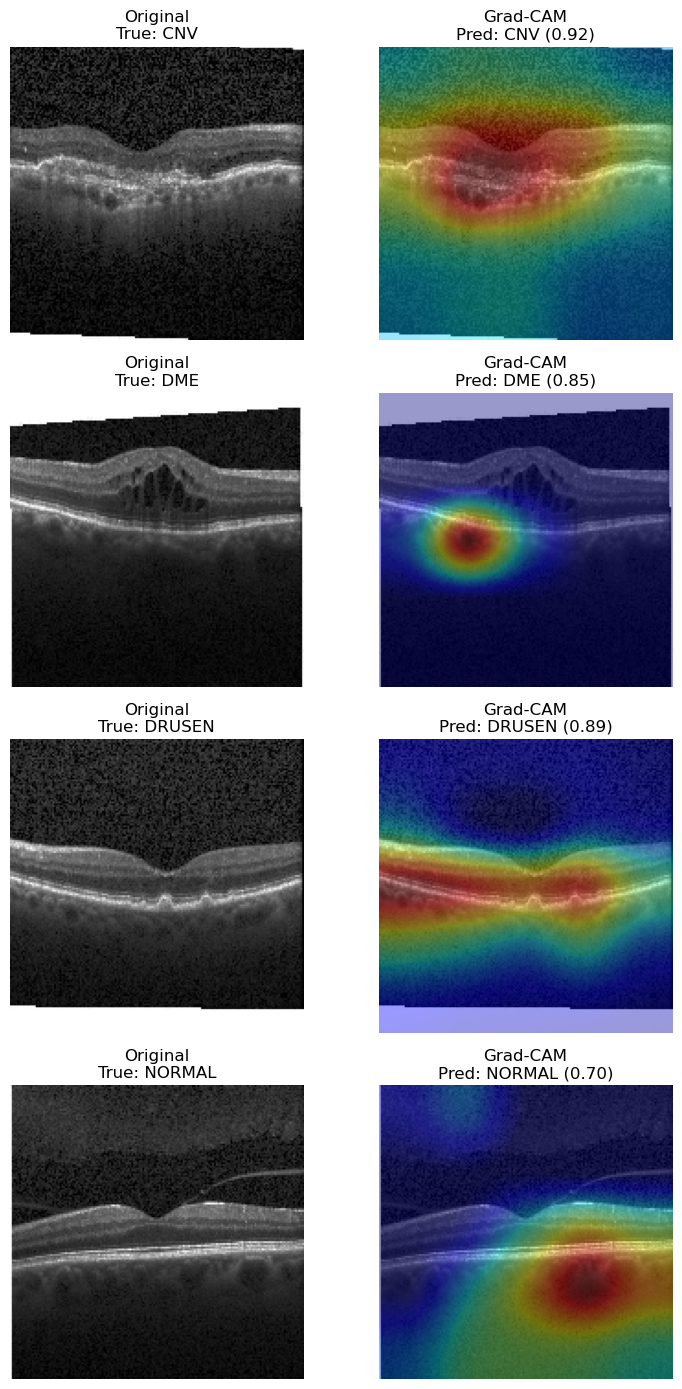

In [49]:
fig, axes = plt.subplots(len(sample_images), 2, figsize=(8, 14))

for i, (true_class, img_path) in enumerate(sample_images):
    img_array = load_image_for_gradcam(img_path, img_size=(160, 160))
    
    heatmap, predictions = make_gradcam_heatmap(img_array, grad_model)
    
    predicted_index = np.argmax(predictions)
    predicted_class = class_names[predicted_index]
    confidence = predictions[predicted_index]
    
    original_img, gradcam_img = overlay_heatmap_on_image(
        img_path,
        heatmap,
        img_size=(160, 160),
        alpha=0.4
    )
    
    axes[i, 0].imshow(original_img.astype("uint8"))
    axes[i, 0].set_title(f"Original\nTrue: {true_class}")
    axes[i, 0].axis("off")
    
    axes[i, 1].imshow(gradcam_img.astype("uint8"))
    axes[i, 1].set_title(
        f"Grad-CAM\nPred: {predicted_class} ({confidence:.2f})"
    )
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

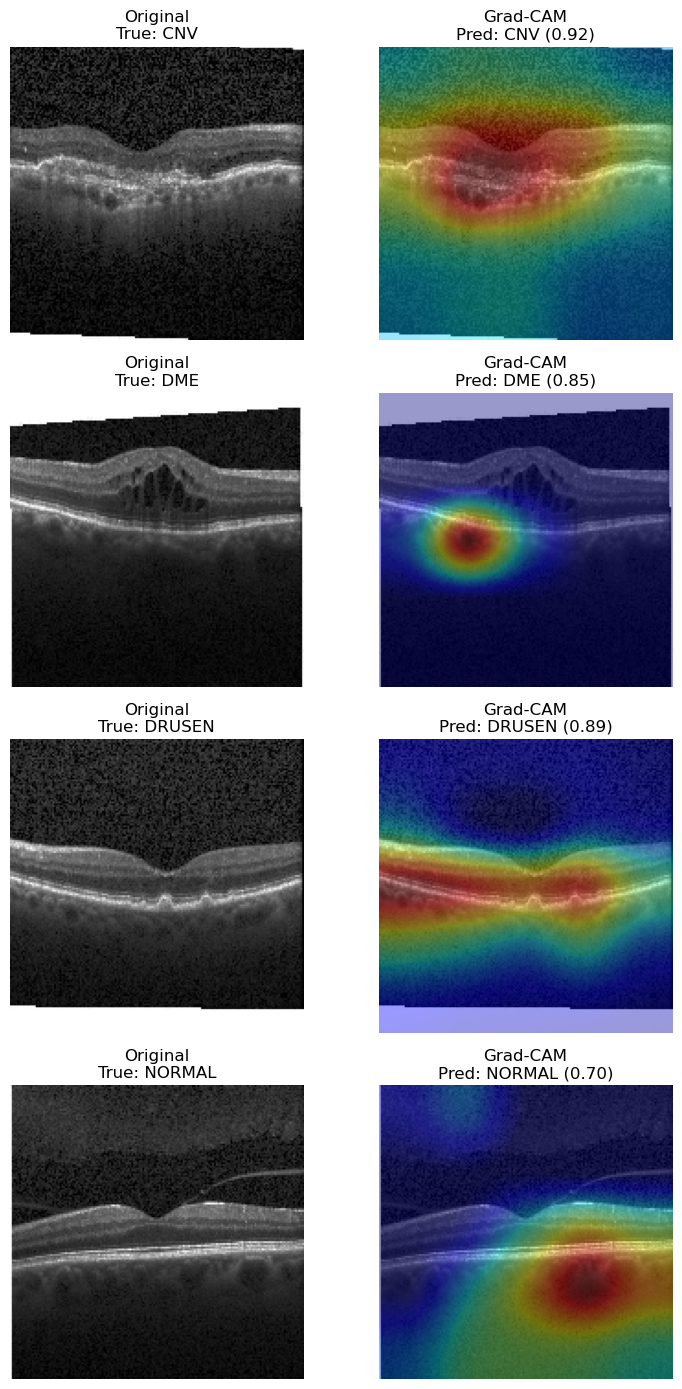

Saved Grad-CAM figure to: C:\Users\chand\Documents\OCT_Project\outputs\efficientnet_gradcam_examples.png


In [50]:
outputs_dir = OUTPUTS_DIR
outputs_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(len(sample_images), 2, figsize=(8, 14))

for i, (true_class, img_path) in enumerate(sample_images):
    img_array = load_image_for_gradcam(img_path, img_size=(160, 160))
    
    heatmap, predictions = make_gradcam_heatmap(img_array, grad_model)
    
    predicted_index = np.argmax(predictions)
    predicted_class = class_names[predicted_index]
    confidence = predictions[predicted_index]
    
    original_img, gradcam_img = overlay_heatmap_on_image(
        img_path,
        heatmap,
        img_size=(160, 160),
        alpha=0.4
    )
    
    axes[i, 0].imshow(original_img.astype("uint8"))
    axes[i, 0].set_title(f"Original\nTrue: {true_class}")
    axes[i, 0].axis("off")
    
    axes[i, 1].imshow(gradcam_img.astype("uint8"))
    axes[i, 1].set_title(
        f"Grad-CAM\nPred: {predicted_class} ({confidence:.2f})"
    )
    axes[i, 1].axis("off")

plt.tight_layout()

save_path = outputs_dir / "efficientnet_gradcam_examples.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved Grad-CAM figure to:", save_path)